# 🍔 Food Delivery Time Prediction — ML Pipeline
**Task:** Regression — Predict `delivery_time_min`  
**Dataset:** 1000 rows, 6 columns  
**Features:** distance_km, prep_time_min, traffic, raining

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import warnings
warnings.filterwarnings('ignore')

print('All libraries imported successfully!')

All libraries imported successfully!


In [15]:
df = pd.read_csv('22_food_delivery.csv')

print('Shape:', df.shape)
print('\nFirst 5 rows:')
df.head()

Shape: (1000, 6)

First 5 rows:


,id,distance_km,prep_time_min,traffic,raining,delivery_time_min
0,1,7.01,13,low,0,32.9
1,2,4.74,19,medium,1,45.0
2,3,3.84,29,low,1,50.8
3,4,4.79,5,high,1,43.6
4,5,5.57,16,high,0,257.5


In [16]:
print('Data Types:')
print(df.dtypes)

print('\nMissing Values:')
print(df.isnull().sum())

print('\nSummary Statistics:')
df.describe()

Data Types:
id                     int64
distance_km          float64
prep_time_min          int64
traffic               object
raining                int64
delivery_time_min    float64
dtype: object

Missing Values:
id                   0
distance_km          0
prep_time_min        0
traffic              0
raining              0
delivery_time_min    0
dtype: int64

Summary Statistics:


,id,distance_km,prep_time_min,raining,delivery_time_min
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,5.051790,19.462000,0.258000,58.579800
std,288.819436,2.750543,7.623823,0.437753,74.221584
min,1.000000,0.500000,5.000000,0.000000,-2.100000
25%,250.750000,3.117500,14.000000,0.000000,34.675000
50%,500.500000,4.920000,20.000000,0.000000,43.900000
75%,750.250000,6.850000,25.000000,1.000000,55.150000
max,1000.000000,14.170000,44.000000,1.000000,765.300000


Target variable stats:
count    1000.000000
mean       58.579800
std        74.221584
min        -2.100000
25%        34.675000
50%        43.900000
75%        55.150000
max       765.300000
Name: delivery_time_min, dtype: float64

Negative delivery times: 1
Delivery times > 200 min: 41


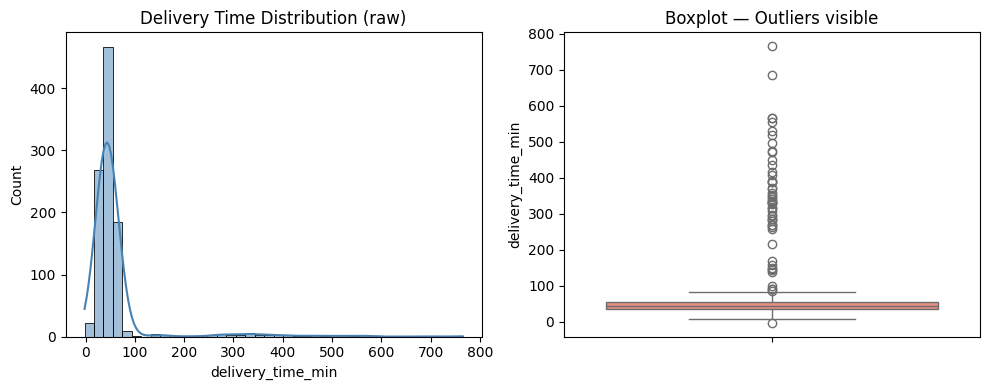

In [17]:
print('Target variable stats:')
print(df['delivery_time_min'].describe())

print(f'\nNegative delivery times: {(df["delivery_time_min"] < 0).sum()}')
print(f'Delivery times > 200 min: {(df["delivery_time_min"] > 200).sum()}')

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.histplot(df['delivery_time_min'], bins=40, kde=True, color='steelblue')
plt.title('Delivery Time Distribution (raw)')

plt.subplot(1, 2, 2)
sns.boxplot(y=df['delivery_time_min'], color='salmon')
plt.title('Boxplot — Outliers visible')

plt.tight_layout()
plt.show()

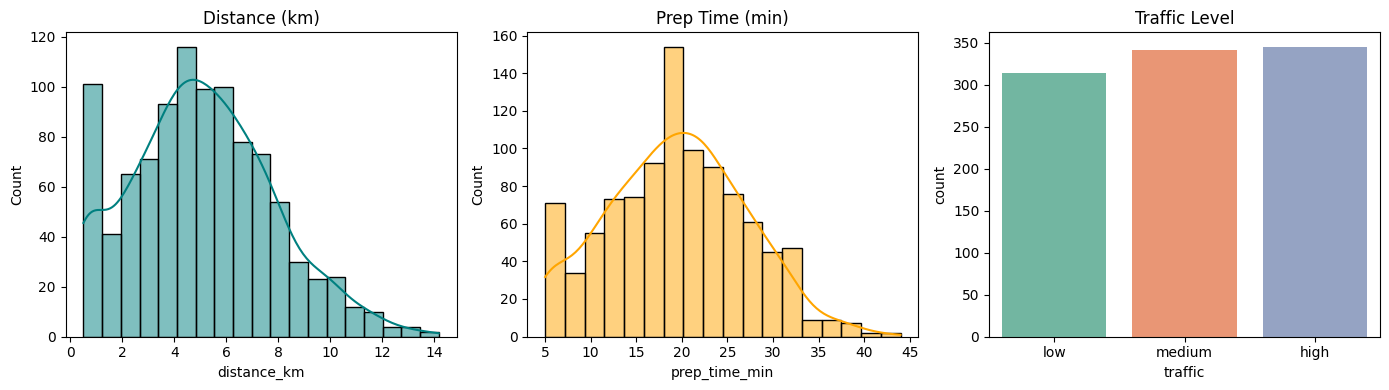

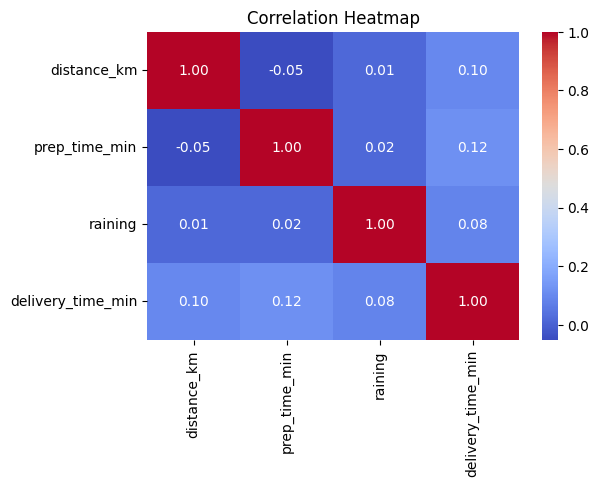

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

sns.histplot(df['distance_km'], ax=axes[0], kde=True, color='teal')
axes[0].set_title('Distance (km)')

sns.histplot(df['prep_time_min'], ax=axes[1], kde=True, color='orange')
axes[1].set_title('Prep Time (min)')

sns.countplot(x='traffic', data=df, ax=axes[2], order=['low','medium','high'], palette='Set2')
axes[2].set_title('Traffic Level')

plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
numeric_df = df.drop(columns=['id', 'traffic'])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

In [19]:
df = df.drop(columns=['id'])

df_clean = df[(df['delivery_time_min'] >= 0) & (df['delivery_time_min'] <= 300)]

print(f'Rows before cleaning: {len(df)}')
print(f'Rows after cleaning:  {len(df_clean)}')
print(f'Rows removed: {len(df) - len(df_clean)}')

Rows before cleaning: 1000
Rows after cleaning:  968
Rows removed: 32


In [20]:
X = df_clean.drop(columns=['delivery_time_min'])
y = df_clean['delivery_time_min']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Training samples: {X_train.shape[0]}')
print(f'Test samples:     {X_test.shape[0]}')
print(f'Features: {list(X.columns)}')

Training samples: 774
Test samples:     194
Features: ['distance_km', 'prep_time_min', 'traffic', 'raining']


In [21]:
categorical_features = ['traffic']
numeric_features = ['distance_km', 'prep_time_min']
binary_features = ['raining']

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_features),
    ('cat', OrdinalEncoder(categories=[['low', 'medium', 'high']]), categorical_features),
    ('bin', 'passthrough', binary_features)
])

print('Preprocessor built successfully!')

Preprocessor built successfully!


In [22]:
pipe_lr = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

pipe_rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(n_estimators=100, random_state=42))
])

pipe_gb = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', GradientBoostingRegressor(n_estimators=100, random_state=42))
])

pipe_lr.fit(X_train, y_train)
pipe_rf.fit(X_train, y_train)
pipe_gb.fit(X_train, y_train)

print('All 3 models trained!')

All 3 models trained!


In [23]:
def evaluate_model(name, pipeline, X_test, y_test):
    y_pred = pipeline.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae  = mean_absolute_error(y_test, y_pred)
    r2   = r2_score(y_test, y_pred)
    print(f'{name}')
    print(f'  RMSE : {rmse:.3f}')
    print(f'  MAE  : {mae:.3f}')
    print(f'  R²   : {r2:.3f}')
    print()
    return {'Model': name, 'RMSE': rmse, 'MAE': mae, 'R2': r2}

results = []
results.append(evaluate_model('Linear Regression',    pipe_lr, X_test, y_test))
results.append(evaluate_model('Random Forest',        pipe_rf, X_test, y_test))
results.append(evaluate_model('Gradient Boosting',    pipe_gb, X_test, y_test))

results_df = pd.DataFrame(results)
results_df

Linear Regression
  RMSE : 17.280
  MAE  : 6.692
  R²   : 0.333

Random Forest
  RMSE : 22.944
  MAE  : 9.055
  R²   : -0.176

Gradient Boosting
  RMSE : 20.768
  MAE  : 8.578
  R²   : 0.037



,Model,RMSE,MAE,R2
0,Linear Regression,17.279650,6.691556,0.333053
1,Random Forest,22.944431,9.054952,-0.175915
2,Gradient Boosting,20.768018,8.578166,0.036589


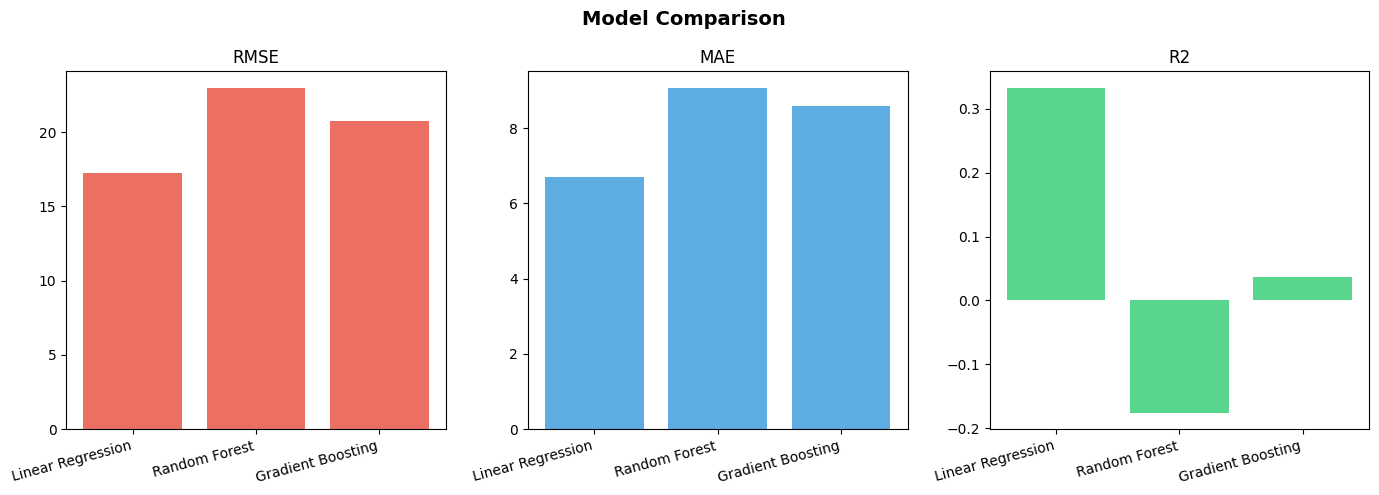

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
metrics = ['RMSE', 'MAE', 'R2']
colors = ['#e74c3c', '#3498db', '#2ecc71']

for ax, metric, color in zip(axes, metrics, colors):
    ax.bar(results_df['Model'], results_df[metric], color=color, alpha=0.8)
    ax.set_title(metric)
    ax.set_xticklabels(results_df['Model'], rotation=15, ha='right')

plt.suptitle('Model Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

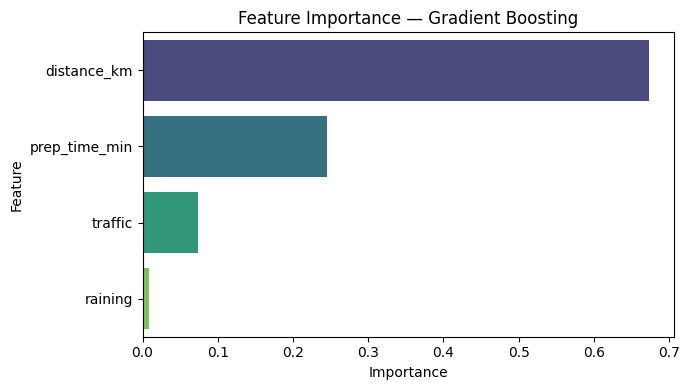

         Feature  Importance
0    distance_km    0.672808
1  prep_time_min    0.245138
2        traffic    0.073707
3        raining    0.008347


In [25]:
feature_names = numeric_features + categorical_features + binary_features
importances = pipe_gb.named_steps['model'].feature_importances_

feat_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feat_imp_df = feat_imp_df.sort_values('Importance', ascending=False)

plt.figure(figsize=(7, 4))
sns.barplot(x='Importance', y='Feature', data=feat_imp_df, palette='viridis')
plt.title('Feature Importance — Gradient Boosting')
plt.tight_layout()
plt.show()

print(feat_imp_df)

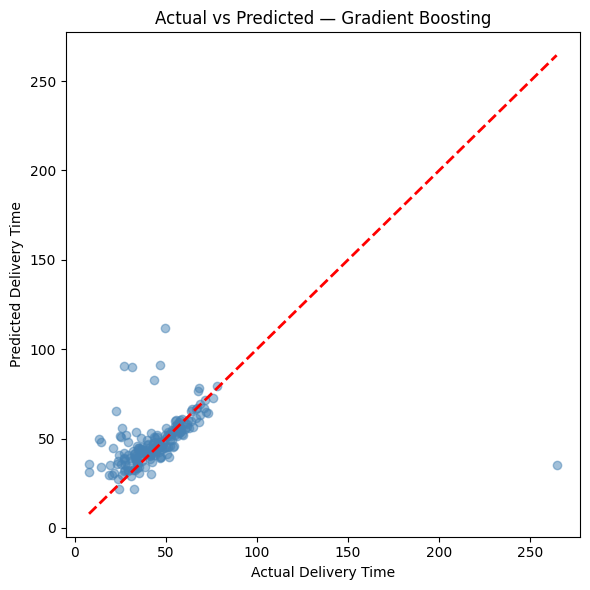

In [26]:
y_pred_gb = pipe_gb.predict(X_test)

plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_gb, alpha=0.5, color='steelblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Delivery Time')
plt.ylabel('Predicted Delivery Time')
plt.title('Actual vs Predicted — Gradient Boosting')
plt.tight_layout()
plt.show()